# 쿠팡 "비피더스균" 상품 분석

## 주제
쿠팡 검색결과에서 수집한 "비피더스균" 유산균 제품 데이터를 바탕으로 가격과 평점의 관계를 살펴봅니다.

## 분석 질문
**가격(단가)이 높을수록 평점도 높을까?**


In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("outputs/coupang_bifidus_final.csv")
print(df.shape)
df.head()


(55, 8)


,product_id,name,price_krw,rating,review_count,page,quantity,unit_price
0,90892125107,"나우그린 정품 프리미엄 비피더스 100, 30정, 3개",54000,5.0,5114.0,1,3,18000.000000
1,95281669913,"락토핏 슈퍼슬림 30p, 60g, 1개",24120,5.0,375.0,1,1,24120.000000
2,90892086477,"나우그린 정품 프리미엄 비피더스 100, 30정, 1개",19900,5.0,5114.0,1,1,19900.000000
3,93350278653,"종근당 장건강 프로젝트365 비피더스 유산균 100억 10.5g, 30정, 2개",32900,5.0,1196.0,1,2,16450.000000
4,95409859880,리얼닥터 비피더스 생유산균 대장건강 배변활동 4종비피더스 면역건강 장건강 국제특허 ...,27400,4.5,138.0,1,3,9133.333333


정제 전 원본 데이터를 불러와 전체 규모를 먼저 확인합니다.

In [2]:
raw = pd.read_csv("outputs/coupang_bifidus_products.csv")
print(f"원본(coupang_bifidus_products.csv) 행 수: {len(raw)}")
raw.head()


원본(coupang_bifidus_products.csv) 행 수: 57


,product_id,name,price_krw,rating,review_count,page
0,90892125107,"나우그린 정품 프리미엄 비피더스 100, 30정, 3개",54000,5.0,5114.0,1
1,95281669913,"락토핏 슈퍼슬림 30p, 60g, 1개",24120,5.0,375.0,1
2,90892086477,"나우그린 정품 프리미엄 비피더스 100, 30정, 1개",19900,5.0,5114.0,1
3,93350278653,"종근당 장건강 프로젝트365 비피더스 유산균 100억 10.5g, 30정, 2개",32900,5.0,1196.0,1
4,95409859880,리얼닥터 비피더스 생유산균 대장건강 배변활동 4종비피더스 면역건강 장건강 국제특허 ...,27400,4.5,138.0,1


리뷰가 없는 신상품은 평점 자체가 없어 분석 대상이 될 수 없으므로, rating 결측 행을 제거합니다.

In [3]:
before_rating = len(raw)
missing_rating = raw[raw["rating"].isna()]
print("rating 결측 상품:")
print(missing_rating[["product_id", "name", "rating", "review_count"]].to_string(index=False))

step1 = raw[raw["rating"].notna()].copy()
print(f"\n행 수 변화: {before_rating} -> {len(step1)} (rating 결측 {before_rating - len(step1)}건 제거)")


rating 결측 상품:
 product_id                                       name  rating  review_count
95818087196 비피젠 퓨어 비피더스 키즈 어린이유산균 프로바이오틱스 특허균, 2g, 60개     NaN           NaN

행 수 변화: 57 -> 56 (rating 결측 1건 제거)


다개입 상품은 총액만으로 비교하면 가격이 왜곡되므로, 상품명에서 개/박스 수량(quantity)을 정규식으로 추출해 개당 단가(unit_price = price_krw / quantity)를 계산합니다. 패턴이 없으면 단일 판매 단위로 보고 quantity=1로 둡니다.

In [4]:
# 콤마/공백/문자열 경계로 둘러싸인 "N개" 또는 "N박스"만 매칭 -> "125ml(8입)x6개"의 6개,
# "1개월"의 1개 같은 오탐은 배제하고, "..., 3개, ..." / "..., 7박스, ..." 같은 진짜 수량 표기만 추출
QTY_PATTERN = re.compile(r'(?:(?<=^)|(?<=[,\s]))(\d+)(?:개|박스)(?=[,\s]|$)')

def extract_quantity(name: str) -> int:
    matches = QTY_PATTERN.findall(name)
    return int(matches[-1]) if matches else 1

step2 = step1.copy()
step2["quantity"] = step2["name"].apply(extract_quantity)
step2["unit_price"] = step2["price_krw"] / step2["quantity"]

print(f"행 수 변화: {len(step1)} -> {len(step2)} (컬럼 추가만 있었으므로 행 수는 그대로)")
print("\nquantity 값 분포:")
print(step2["quantity"].value_counts().sort_index())


행 수 변화: 56 -> 56 (컬럼 추가만 있었으므로 행 수는 그대로)

quantity 값 분포:
quantity
1     23
2     15
3      8
4      2
5      1
6      3
7      1
9      1
12     1
48     1
Name: count, dtype: int64


액상(파우치) 제품은 정/캡슐과 판매 단위(개)의 성격이 달라 단가를 직접 비교할 수 없으므로 제외합니다.

In [5]:
before_form = len(step2)

form_keywords = ["ml", "액상", "파우치", "스틱", "젤리", "츄어블", "분말",
                  "리퀴드", "드링크", "음료", "시럽", "젤", "워터", "주스"]
liquid_mask = step2["name"].str.contains("|".join(form_keywords), case=False, regex=True)

print("제형이 다른(액상 등) 것으로 감지된 상품:")
print(step2[liquid_mask][["product_id", "name", "price_krw", "quantity"]].to_string(index=False))

step3 = step2[~liquid_mask].copy()
print(f"\n행 수 변화: {before_form} -> {len(step3)} (제형 다른 상품 {before_form - len(step3)}건 제외)")


제형이 다른(액상 등) 것으로 감지된 상품:
 product_id                                 name  price_krw  quantity
86407483497 동원 명장비피더스 사과125ml(8입)x6개, 48개, 125ml      16730        48

행 수 변화: 56 -> 55 (제형 다른 상품 1건 제외)


전체 정제 과정의 행 수 변화를 한눈에 정리하고, 최종 데이터를 다음 분석 단계에서 재사용할 수 있도록 CSV로 저장합니다.

In [6]:
print("=== 정제 단계별 행 수 변화 ===")
print(f"원본                : {len(raw)}행")
print(f"rating 결측 제거 후 : {len(step1)}행")
print(f"quantity/unit_price 계산 후 : {len(step2)}행")
print(f"제형 다른 상품 제외 후      : {len(step3)}행")

df = step3.reset_index(drop=True)
df.to_csv("outputs/coupang_bifidus_final.csv", index=False, encoding="utf-8-sig")
print(f"\n저장 완료: outputs/coupang_bifidus_final.csv ({len(df)}행)")
df.head()


=== 정제 단계별 행 수 변화 ===
원본                : 57행
rating 결측 제거 후 : 56행
quantity/unit_price 계산 후 : 56행
제형 다른 상품 제외 후      : 55행

저장 완료: outputs/coupang_bifidus_final.csv (55행)


,product_id,name,price_krw,rating,review_count,page,quantity,unit_price
0,90892125107,"나우그린 정품 프리미엄 비피더스 100, 30정, 3개",54000,5.0,5114.0,1,3,18000.000000
1,95281669913,"락토핏 슈퍼슬림 30p, 60g, 1개",24120,5.0,375.0,1,1,24120.000000
2,90892086477,"나우그린 정품 프리미엄 비피더스 100, 30정, 1개",19900,5.0,5114.0,1,1,19900.000000
3,93350278653,"종근당 장건강 프로젝트365 비피더스 유산균 100억 10.5g, 30정, 2개",32900,5.0,1196.0,1,2,16450.000000
4,95409859880,리얼닥터 비피더스 생유산균 대장건강 배변활동 4종비피더스 면역건강 장건강 국제특허 ...,27400,4.5,138.0,1,3,9133.333333


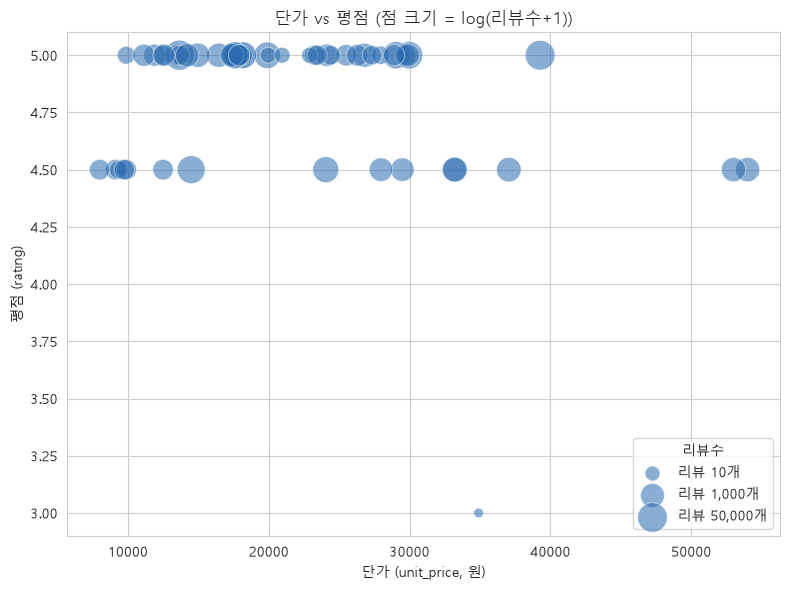

In [7]:
df["log_review"] = np.log(df["review_count"] + 1)

fig, ax = plt.subplots(figsize=(8, 6))
sizes = df["log_review"] * 40 + 20
ax.scatter(
    df["unit_price"], df["rating"],
    s=sizes, color="#2b6cb0", alpha=0.55, edgecolors="white", linewidths=0.6,
)
ax.set_xlabel("단가 (unit_price, 원)")
ax.set_ylabel("평점 (rating)")
ax.set_title("단가 vs 평점 (점 크기 = log(리뷰수+1))")

for review_ref, label in [(10, "리뷰 10개"), (1000, "리뷰 1,000개"), (50000, "리뷰 50,000개")]:
    s = np.log(review_ref + 1) * 40 + 20
    ax.scatter([], [], s=s, color="#2b6cb0", alpha=0.55, edgecolors="white", linewidths=0.6, label=label)
ax.legend(title="리뷰수", loc="lower right", frameon=True)

fig.tight_layout()
plt.show()


점들이 4.5와 5.0 두 줄에 나란히 몰려있어, 단가와 평점 사이 뚜렷한 추세선은 보이지 않는다. 유일한 3.0점 상품(단가 약 35,000원)은 리뷰 수가 적어(점 크기 작음) 평점 하나의 극단치로 보인다.

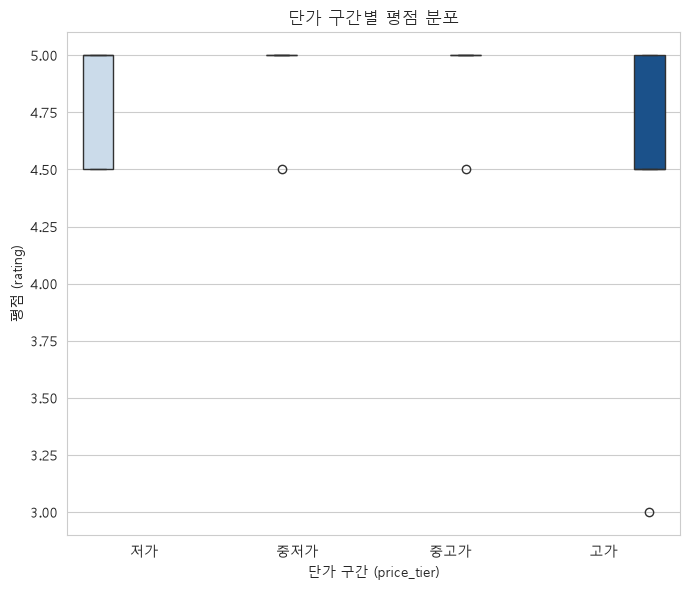

In [8]:
labels = ["저가", "중저가", "중고가", "고가"]
df["price_tier"] = pd.qcut(df["unit_price"], q=4, labels=labels)

palette = {"저가": "#c6dbef", "중저가": "#6baed6", "중고가": "#3182bd", "고가": "#08519c"}

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(
    data=df, x="price_tier", y="rating", order=labels,
    hue="price_tier", palette=palette, legend=False, ax=ax,
)
ax.set_xlabel("단가 구간 (price_tier)")
ax.set_ylabel("평점 (rating)")
ax.set_title("단가 구간별 평점 분포")

fig.tight_layout()
plt.show()


저가·고가 구간만 박스(4.5~5.0)가 있고, 중저가·중고가는 거의 모든 값이 5.0에 쏠려 박스가 선처럼 보인다. 고가 구간에만 3.0인 이상치가 하나 있을 뿐, 구간 간 평점 중앙값 차이는 사실상 없다.

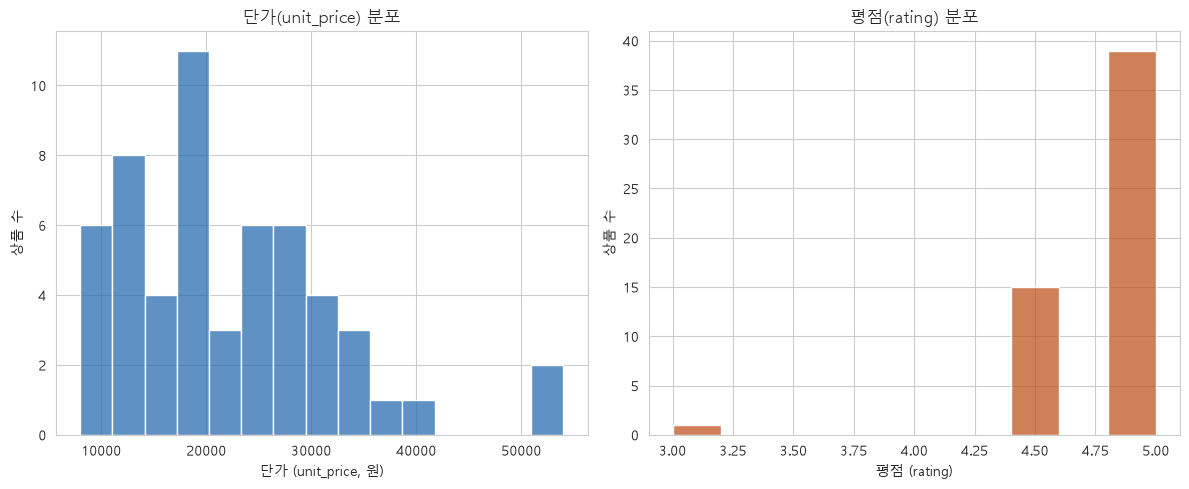

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["unit_price"], bins=15, color="#2b6cb0", ax=axes[0])
axes[0].set_xlabel("단가 (unit_price, 원)")
axes[0].set_ylabel("상품 수")
axes[0].set_title("단가(unit_price) 분포")

sns.histplot(df["rating"], bins=10, color="#c05621", ax=axes[1])
axes[1].set_xlabel("평점 (rating)")
axes[1].set_ylabel("상품 수")
axes[1].set_title("평점(rating) 분포")

fig.tight_layout()
plt.show()


단가는 10,000~30,000원대에 집중되며 완만한 종형 분포에 가깝지만, 평점은 5.0(39건)에 압도적으로 몰리고 3.0은 단 1건뿐인 극단적 비대칭 분포를 보인다.

## 데이터 분석 정리

**데이터 출처:** https://www.coupang.com/np/search?q=비피더스균
**수집 일시:** 2026-07-23
**원본 데이터:** coupang_bifidus_products.csv (57행)
**최종 정제 데이터:** coupang_bifidus_final.csv (55행)

### 1. 주제
쿠팡 "비피더스균" 유산균 제품

### 2. 분석 질문
가격(단가)이 높을수록 평점도 높을까?

### 3. 데이터 수집 및 정제
- Playwright(patchright) 스크래핑, 쿠팡 검색결과 1페이지 57건 수집 (robots.txt 확인 결과 /np/search 수집 허용됨)
- 결측치 1건(신상품, 리뷰 없음) 제거 → 56건
- 다개입 상품(개/박스 단위 혼재)을 상품명에서 정규식으로 추출해 unit_price(단가) 컬럼 생성
- 제형이 다른 액상(파우치) 상품 1건 제외 (정/캡슐과 단위 비교 불가) → 최종 55건

### 4. 알게 된 점
- 단가와 평점 사이에 뚜렷한 선형 관계는 확인되지 않았다.
- 평점 자체가 3.0/4.5/5.0 등 소수 값에 극도로 쏠려있기 때문(5.0이 39건, 전체 71%) — "평점 인플레이션" 현상으로 보인다.
- 반면 단가는 저가~고가 구간에 비교적 고르게 분포해, 데이터 자체는 분석하기에 충분한 다양성을 가지고 있었다.

### 5. 데이터 편향 및 한계
- 쿠팡 검색결과 1페이지만 수집(2페이지는 봇 차단으로 실패) — 기본 정렬 기준(관련도/판매량순)에 따라 인기 상품 위주로 편향되어 있을 가능성이 있다.
- 판매량이 낮거나 신규 입점한 상품은 이 데이터에 잘 반영되지 않았을 수 있다.
- 가격은 수집 시점(2026-07-23) 기준이며, 세일/프로모션 여부에 따라 달라질 수 있다.
- 다개입(박스/세트) 단위를 단가로 환산했지만, 박스당 실제 내용물 수는 개별 확인하지 않아 일부 오차 가능성이 있다.
- 리뷰 수나 리뷰 텍스트 감성분석 같은 변수와 교차 분석하면 더 유의미한 결과를 얻을 수 있을 것으로 예상된다.
